### Level 2
## Task 2: Classification with Logistic Regression

In [1]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [6]:
df=pd.read_csv("C:/Users/Aditya Kumar Singh/Desktop/InternShip/CodeVeda/DataSets/Data_Sets/1) iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


the indexing has no relation in real time

In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [12]:
df['species'].value_counts()
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
df['species_encoded']= le.fit_transform(df['species'])
df[['species','species_encoded']].head(10)

,species,species_encoded
0,setosa,0
1,setosa,0
2,setosa,0
3,setosa,0
4,setosa,0
5,setosa,0
6,setosa,0
7,setosa,0
8,setosa,0
9,setosa,0


In [15]:
from sklearn.model_selection import train_test_split as tts
X= df.drop(['species','species_encoded'], axis=1)
y=df['species_encoded']
X_train,X_test,y_train,y_test= tts(X,y, test_size=0.2, random_state=42)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [16]:
#Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_train_scaled[0])

[-1.47393679  1.22037928 -1.5639872  -1.30948358]


In [20]:
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred= log_model.predict(X_test_scaled)
print("Model Predictions: ", log_pred[:5])
print("Actual Answers:    ", y_test[:5].values)

Model Predictions:  [1 0 2 1 1]
Actual Answers:     [1 0 2 1 1]


Overall accuracy: 100.0

Classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



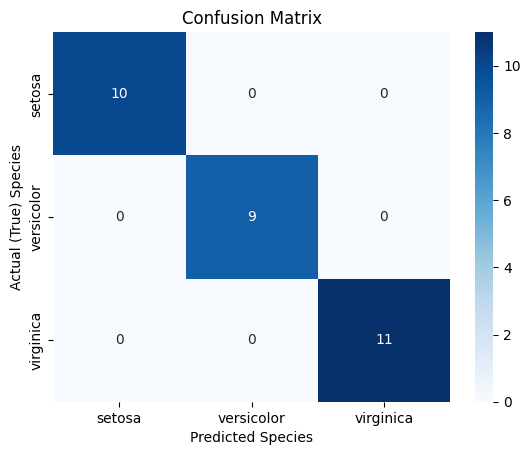

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy= accuracy_score(y_test, log_pred)
print("Overall accuracy:", accuracy*100)
print('\nClassification report:\n', classification_report(y_test,log_pred, target_names=le.classes_))
cm= confusion_matrix(y_test,log_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Species')
plt.ylabel('Actual (True) Species')
plt.title('Confusion Matrix')
plt.show()

Comparing with other classification models

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled,y_train)
rf_pred= rf_model.predict(X_test_scaled)
rf_accuracy= accuracy_score(y_test,rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 100.00%


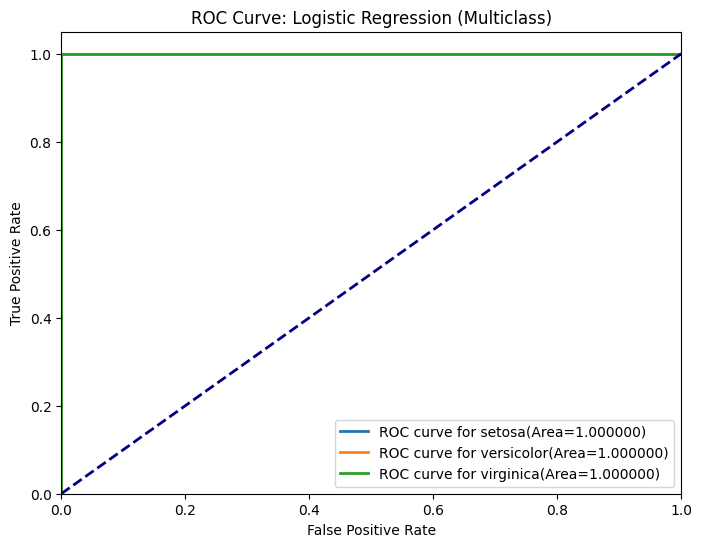

In [26]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
y_test_binary=label_binarize(y_test, classes=[0,1,2])
y_score=log_model.predict_proba(X_test_scaled)
plt.figure(figsize=(8,6))
for i in range(3):
    fpr,tpr, _= roc_curve(y_test_binary[:,i],y_score[:,i])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr, lw=2, label=f'ROC curve for {le.classes_[i]}(Area={roc_auc:2f})')
plt.plot([0,1],[0,1], color='navy',lw=2,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Logistic Regression (Multiclass)')
plt.legend(loc="lower right")
plt.show()

## Project Overview
The objective of this task was to build a classification model to predict the species of Iris flowers based on their physical measurements (sepal and petal length/width). We implemented a Logistic Regression model, compared it against a Random Forest classifier, and evaluated the performance using classification-specific metrics.

## Step-by-Step Analysis & Implementation

### 1. Data Inspection & Cleaning
* **Observation:** The dataset contains 150 rows and 6 columns with 0 missing values.
* **Action taken:** We identified that the auto-generated index/ID column held no predictive value for the flower species. We strictly used the 4 biological measurements as our features.

### 2. Target Variable Preprocessing
* **Class Balance:** A check of `value_counts()` revealed a perfectly balanced dataset (50 Setosa, 50 Versicolor, 50 Virginica), meaning our model would not suffer from class bias.
* **Label Encoding:** Since machine learning equations require numerical inputs, we used `LabelEncoder` to convert the categorical target (`species`) into integers: Setosa (0), Versicolor (1), and Virginica (2).

### 3. Data Splitting & Feature Scaling
* **Train-Test Split:** The data was split into 80% training (120 samples) and 20% testing (30 samples) using `random_state=42` for reproducibility.
* **Scaling to Prevent Data Leakage:** We applied `StandardScaler` to normalize the feature ranges. To strictly prevent data leakage, the scaler was *fitted and transformed* on the training data, but *only transformed* on the testing data.

### 4. Logistic Regression Training & Evaluation
* **Model Choice:** We transitioned from Regression metrics (MSE, R²) to Classification metrics (Accuracy, Precision, Recall) because we are predicting discrete categories, not continuous numbers.
* **Results:** The Logistic Regression model achieved **100% Accuracy**. 
* **Confusion Matrix:** The heatmap showed a perfect diagonal line with zero misclassifications (0 false positives, 0 false negatives).

### 5. Model Comparison
* **Random Forest Baseline:** To satisfy the task requirements and test for alternative patterns, we trained a Random Forest Classifier. 
* **Comparison:** The Random Forest also achieved 100% accuracy, resulting in a tie. For this specific, highly linear dataset, both models easily found the separation boundaries.

### 6. ROC Curve Analysis
* **Multiclass Strategy:** Because ROC curves are designed for binary problems, we utilized the **One-vs-Rest (OvR)** strategy, converting the labels into a binarized format to plot separate curves for each species against the rest.
* **Visual Analysis:** All three class lines formed perfect right angles in the top-left corner, resulting in an **Area Under the Curve (AUC) of 1.00**. This visually confirms that the model has perfect confidence and zero overlap when distinguishing between the three species.

## Conclusion
The Logistic Regression model was successfully trained and evaluated, achieving perfect predictive accuracy (100% Accuracy, 1.0 AUC) on the test set. All task requirements, including preprocessing, model comparison, and ROC evaluation, have been fully met.